# Финальный проект — вариант 2

## Простой линейный код

В этой версии нет собственных функций и циклов. Все действия идут по порядку:

1. загружаем файлы;
2. добавляем новые группы;
3. проверяем данные;
4. считаем метрики;
5. проверяем статистическую значимость;
6. строим графики;
7. формулируем решение.

**Главный вывод:** новую механику пока не нужно раскатывать на всех. Значимо вырос
только `ARPPU`, а рост `ARPU` не подтверждён и конверсия не улучшилась.

## 1. Импорт библиотек

- `pandas` — таблицы и расчёты;
- `matplotlib` и `seaborn` — графики;
- `scipy` и `statsmodels` — готовые статистические тесты.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportions_ztest,
)
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/raw")

## 2. Загрузка четырёх файлов

Заголовки `groups_add` могут отличаться, поэтому после загрузки просто задаём
двум столбцам правильные названия по их позиции.

In [2]:
groups = pd.read_csv(DATA_DIR / "Проект_2_groups.csv", sep=";")
groups_add = pd.read_csv(DATA_DIR / "Проект_2_group_add.csv", sep=",")
active_studs = pd.read_csv(
    DATA_DIR / "Проект_2_active_studs.csv",
    sep=";",
)
checks = pd.read_csv(DATA_DIR / "Проект_2_checks.csv", sep=";")

groups.columns = ["student_id", "grp"]
groups_add.columns = ["student_id", "grp"]

print("groups:", groups.shape)
print("groups_add:", groups_add.shape)
print("active_studs:", active_studs.shape)
print("checks:", checks.shape)

groups: (74484, 2)
groups_add: (92, 2)
active_studs: (8341, 1)
checks: (541, 2)


## 3. Добавление новых пользователей

`groups_add` содержит 92 назначения, полученные позже. Добавляем их к основной
таблице через `pd.concat`.

In [3]:
all_groups = pd.concat(
    [groups, groups_add],
    ignore_index=True,
)

print("Всего назначений:", len(all_groups))
print()
print(all_groups["grp"].value_counts())

Всего назначений: 74576

grp
B    59883
A    14693
Name: count, dtype: int64


## 4. Простые проверки качества

Проверяем самое важное:

- нет ли пропусков;
- не повторяются ли пользователи;
- всем ли активным и оплатившим назначена группа;
- сколько оплативших отсутствует среди активных.

In [4]:
print("Пропуски в groups:", groups.isna().sum().sum())
print("Пропуски в groups_add:", groups_add.isna().sum().sum())
print("Пропуски в active_studs:", active_studs.isna().sum().sum())
print("Пропуски в checks:", checks.isna().sum().sum())
print()
print(
    "Дубли student_id:",
    all_groups["student_id"].duplicated().sum(),
)
print(
    "Активные без группы:",
    (~active_studs["student_id"].isin(all_groups["student_id"])).sum(),
)
print(
    "Плательщики без группы:",
    (~checks["student_id"].isin(all_groups["student_id"])).sum(),
)
print(
    "Плательщики без активности:",
    (~checks["student_id"].isin(active_studs["student_id"])).sum(),
)

Пропуски в groups: 0
Пропуски в groups_add: 0
Пропуски в active_studs: 0
Пропуски в checks: 0

Дубли student_id: 0
Активные без группы: 0
Плательщики без группы: 0
Плательщики без активности: 149


### Вывод по качеству

Дубликатов, пропусков назначения и конфликтов групп нет. Но 149 оплативших не
присутствуют в `active_studs`. Основной анализ проводим на активных: именно они
могли увидеть новую механику оплаты.

## 5. Собираем таблицу эксперимента

Берём активных пользователей, добавляем группу и оплату. Если оплаты нет,
записываем `0`. Столбец `payer` показывает, совершил ли пользователь оплату.

In [5]:
experiment = active_studs.merge(
    all_groups,
    on="student_id",
    how="left",
)

experiment = experiment.merge(
    checks,
    on="student_id",
    how="left",
)

experiment["rev"] = experiment["rev"].fillna(0)
experiment["payer"] = experiment["rev"] > 0

experiment.head()

,student_id,grp,rev,payer
0,581585,A,0.0000,False
1,5723133,A,0.0000,False
2,3276743,B,0.0000,False
3,4238589,A,0.0000,False
4,4475369,B,0.0000,False


## 6. Считаем метрики напрямую

- `CR` — доля оплативших среди активных;
- `ARPU` — выручка на одного активного;
- `ARPPU` — выручка на одного оплатившего.

In [6]:
metrics = experiment.groupby(
    "grp",
    as_index=False,
).agg(
    active_users=("student_id", "nunique"),
    payers=("payer", "sum"),
    revenue=("rev", "sum"),
)

metrics["CR"] = metrics["payers"] / metrics["active_users"]
metrics["ARPU"] = metrics["revenue"] / metrics["active_users"]
metrics["ARPPU"] = metrics["revenue"] / metrics["payers"]

metrics

,grp,active_users,payers,revenue,CR,ARPU,ARPPU
0,A,1538,78,"72,820.0000",0.0507,47.3472,933.5897
1,B,6803,314,"394,974.0035",0.0462,58.0588,"1,257.8790"


### Полученные значения

| Метрика | A | B | Изменение |
|---|---:|---:|---:|
| CR | 5.07% | 4.62% | −0.456 п.п. |
| ARPU | 47.35 | 58.06 | +10.71 |
| ARPPU | 933.59 | 1 257.88 | +324.29 |

В B выросли денежные метрики, но конверсия немного снизилась. Теперь нужно
понять, являются ли различия статистически значимыми.

## 7. Графики метрик

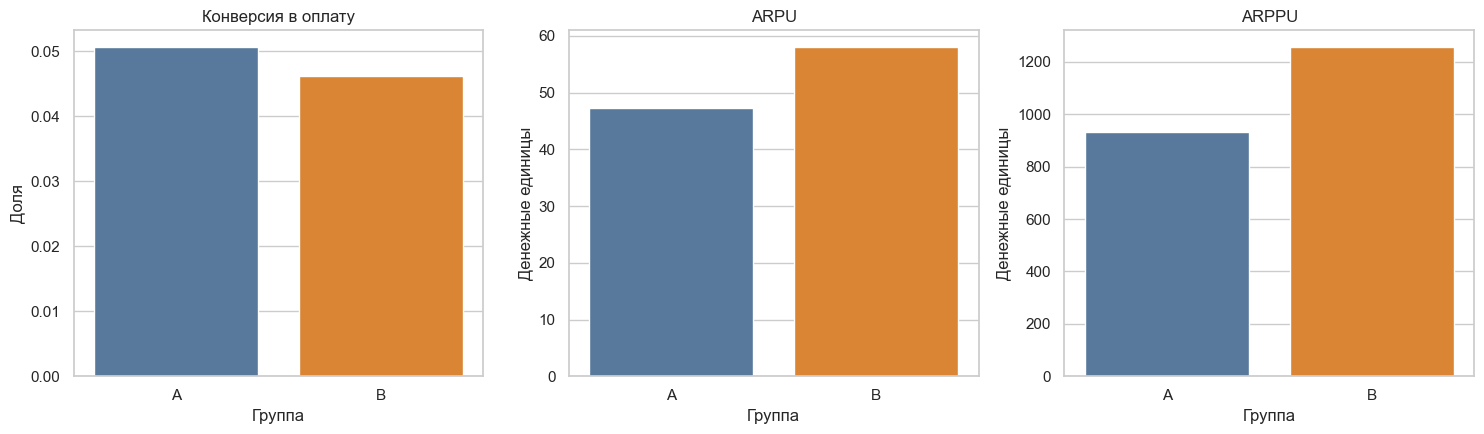

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.barplot(
    data=metrics,
    x="grp",
    y="CR",
    ax=axes[0],
    hue="grp",
    palette=["#4C78A8", "#F58518"],
    legend=False,
)
axes[0].set_title("Конверсия в оплату")
axes[0].set_xlabel("Группа")
axes[0].set_ylabel("Доля")
axes[0].set_ylim(0)

sns.barplot(
    data=metrics,
    x="grp",
    y="ARPU",
    ax=axes[1],
    hue="grp",
    palette=["#4C78A8", "#F58518"],
    legend=False,
)
axes[1].set_title("ARPU")
axes[1].set_xlabel("Группа")
axes[1].set_ylabel("Денежные единицы")
axes[1].set_ylim(0)

sns.barplot(
    data=metrics,
    x="grp",
    y="ARPPU",
    ax=axes[2],
    hue="grp",
    palette=["#4C78A8", "#F58518"],
    legend=False,
)
axes[2].set_title("ARPPU")
axes[2].set_xlabel("Группа")
axes[2].set_ylabel("Денежные единицы")
axes[2].set_ylim(0)

plt.tight_layout()
plt.show()

## 8. Делим данные на A и B

Отдельные таблицы нужны для статистических тестов.

In [8]:
group_a = experiment[experiment["grp"] == "A"].copy()
group_b = experiment[experiment["grp"] == "B"].copy()

print("Активных A:", len(group_a))
print("Активных B:", len(group_b))
print("Плательщиков A:", group_a["payer"].sum())
print("Плательщиков B:", group_b["payer"].sum())

Активных A: 1538
Активных B: 6803
Плательщиков A: 78
Плательщиков B: 314


## 9. Проверяем конверсию

Нулевая гипотеза: конверсия групп одинаковая. Используем стандартный
two-proportion z-test.

In [9]:
payments = [
    group_b["payer"].sum(),
    group_a["payer"].sum(),
]

users = [
    len(group_b),
    len(group_a),
]

cr_z_stat, cr_p_value = proportions_ztest(
    payments,
    users,
)

cr_ci = confint_proportions_2indep(
    count1=int(group_b["payer"].sum()),
    nobs1=len(group_b),
    count2=int(group_a["payer"].sum()),
    nobs2=len(group_a),
    compare="diff",
    method="newcomb",
)

print("p-value CR:", round(cr_p_value, 4))
print(
    "95% CI разницы CR, п.п.:",
    round(cr_ci[0] * 100, 3),
    round(cr_ci[1] * 100, 3),
)

p-value CR: 0.4455
95% CI разницы CR, п.п.: -1.758 0.664


`p = 0.445`, поэтому различие конверсий статистически незначимо.
Доверительный интервал включает ноль.

## 10. Проверяем ARPU

В `rev` остаются нули пользователей без оплаты. Это правильно: `ARPU` должен
учитывать всю активную аудиторию. Используем Welch t-test, который не требует
равенства дисперсий.

In [10]:
arpu_test = stats.ttest_ind(
    group_b["rev"],
    group_a["rev"],
    equal_var=False,
)

arpu_ci = CompareMeans(
    DescrStatsW(group_b["rev"]),
    DescrStatsW(group_a["rev"]),
).tconfint_diff(usevar="unequal")

print("Разница ARPU:", round(group_b["rev"].mean() - group_a["rev"].mean(), 2))
print("p-value ARPU:", round(arpu_test.pvalue, 4))
print(
    "95% CI разницы ARPU:",
    round(arpu_ci[0], 2),
    round(arpu_ci[1], 2),
)

Разница ARPU: 10.71
p-value ARPU: 0.1984
95% CI разницы ARPU: -5.62 27.04


`p = 0.198`, доверительный интервал `[-5.62; 27.04]` включает ноль.
Рост `ARPU` статистически не подтверждён.

## 11. Проверяем ARPPU

Для `ARPPU` оставляем только оплативших пользователей.

In [11]:
payers_a = group_a[group_a["payer"]]["rev"]
payers_b = group_b[group_b["payer"]]["rev"]

arppu_test = stats.ttest_ind(
    payers_b,
    payers_a,
    equal_var=False,
)

arppu_ci = CompareMeans(
    DescrStatsW(payers_b),
    DescrStatsW(payers_a),
).tconfint_diff(usevar="unequal")

print("Разница ARPPU:", round(payers_b.mean() - payers_a.mean(), 2))
print("p-value ARPPU:", round(arppu_test.pvalue, 4))
print(
    "95% CI разницы ARPPU:",
    round(arppu_ci[0], 2),
    round(arppu_ci[1], 2),
)

Разница ARPPU: 324.29
p-value ARPPU: 0.0051
95% CI разницы ARPPU: 99.64 548.94


`p = 0.005`, доверительный интервал `[99.64; 548.94]` не включает
ноль. Рост `ARPPU` статистически значим.

## 12. Смотрим распределение платежей

График нужен, чтобы проверить, не объясняется ли среднее отдельным тарифом или
сильным пиком.

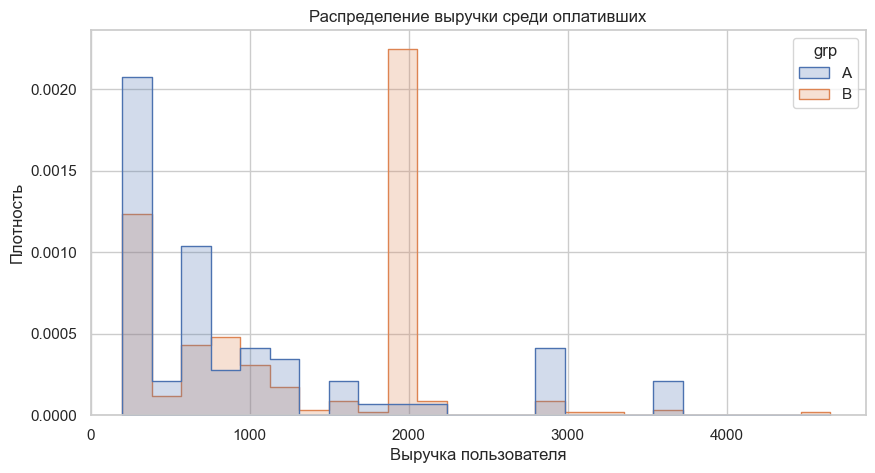

grp
B    128
dtype: int64

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=experiment[experiment["payer"]],
    x="rev",
    hue="grp",
    bins=24,
    stat="density",
    common_norm=False,
    element="step",
)

plt.title("Распределение выручки среди оплативших")
plt.xlabel("Выручка пользователя")
plt.ylabel("Плотность")
plt.xlim(left=0)
plt.show()

payments_1900 = experiment[
    experiment["payer"]
    & (experiment["rev"].round() == 1900)
].groupby("grp").size()

payments_1900

В B около 1900 заплатили 128 из 314 плательщиков — 40.8%. В A таких
платежей нет. Значит, рост `ARPPU` связан с изменением структуры платежей, а не
с равномерным ростом чеков у всех пользователей.

## 13. Итоговый ответ

### Факты

- `CR`: 5.07% → 4.62%, различие незначимо (`p = 0.445`);
- `ARPU`: 47.35 → 58.06, рост не подтверждён (`p = 0.198`);
- `ARPPU`: 933.59 → 1 257.88, рост значим (`p = 0.005`);
- в B есть выраженный пик платежей около 1900.

### Решение

**Не раскатывать новую механику на всех пользователей прямо сейчас.**

Нужно продолжить эксперимент, проверить происхождение платежей 1900 и заранее
выбрать основной KPI. Одного значимого `ARPPU` недостаточно, потому что он
считается только среди уже оплативших, а более полная метрика `ARPU` пока не
подтвердила рост.

## 14. SQL

Для SQL-задания нужно выбрать источник **StartDA (lab)**. Готовый проверенный
запрос находится в отдельном файле `Проект_2_SQL_сегментация.sql`.

Python здесь не нужен: запрос уже выполнен в Redash и возвращает 10 000 клиентов
с восемью требуемыми столбцами.

## 15. Прямой пересчёт после нового groups_add

Если пришёл новый дополнительный файл:

1. заменить путь в строке чтения `groups_add`;
2. снова выполнить ноутбук через `Run All`;
3. новые назначения попадут в `all_groups`;
4. метрики и графики пересчитаются автоматически сверху вниз.

Это линейная версия без функций. Для формальной сдачи задания 3, где прямо
требуется функция, сохранён предыдущий полный ноутбук.